# 🏬 Data Warehouse - Sample Superstore
**UTS Business Intelligence**

Dataset: Sample Superstore (Retail Transactions USA, 2014–2017)

**Alur Notebook:**
1. Load & Eksplorasi Data (EDA)
2. ETL (Extract → Transform → Load ke Star Schema)
3. Analisis Data & Visualisasi


---
## 1. Setup & Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('Library berhasil diimport')

✅ Library berhasil diimport


---
## 2. EXTRACT — Load Data Sumber

In [ ]:
df_raw = pd.read_csv('/content/Sample_ Superstore.csv', encoding='latin1')

print('Shape data:', df_raw.shape)
print('Kolom:', df_raw.columns.tolist())
df_raw.head()

Shape data: (9994, 19)
Kolom: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Cek tipe data dan missing values
print('=== Tipe Data ===')
print(df_raw.dtypes)
print()
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print()
print('=== Duplikat ===')
print('Jumlah baris duplikat:', df_raw.duplicated().sum())

=== Tipe Data ===
Row ID            int64
Order ID         object
Order Date       object
Ship Date        object
Ship Mode        object
Customer ID      object
Segment          object
Country          object
City             object
State            object
Region           object
Product ID       object
Category         object
Sub-Category     object
Product Name     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

=== Missing Values ===
Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

=== Duplikat ===
Jumlah baris duplikat: 0


In [ ]:
# Statistik deskriptif kolom numerik
df_raw[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


---
## 3. TRANSFORM — Pembersihan & Persiapan Data

In [ ]:
df = df_raw.copy()

# 1. Konversi tipe tanggal
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='mixed')

# 2. Tambah kolom turunan tanggal
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Ship Delay']    = (df['Ship Date'] - df['Order Date']).dt.days  # hari pengiriman

# 3. Tambah kolom Profit Margin per transaksi
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

print('✅ Transformasi dasar selesai')
df[['Order Date','Order Year','Order Month','Order Quarter','Ship Delay','Profit Margin %']].head()

✅ Transformasi dasar selesai


,Order Date,Order Year,Order Month,Order Quarter,Ship Delay,Profit Margin %
0,2016-11-08,2016,11,4,3,16.00
1,2016-11-08,2016,11,4,3,30.00
2,2016-06-12,2016,6,2,4,47.00
3,2015-10-11,2015,10,4,7,-40.00
4,2015-10-11,2015,10,4,7,11.25


In [ ]:
# Cek nilai negatif pada Profit (transaksi merugi)
loss_count = (df['Profit'] < 0).sum()
print(f'Transaksi merugi (Profit < 0): {loss_count} dari {len(df)} ({loss_count/len(df)*100:.1f}%)')

Transaksi merugi (Profit < 0): 1871 dari 9994 (18.7%)


---
## 4. LOAD — Bangun Star Schema (DataFrame)

```
                ┌──────────────┐
                │  dim_date    │
                └──────┬───────┘
  ┌─────────────┐      │      ┌──────────────────┐
  │ dim_customer│──────┤      ├─── dim_product    │
  └─────────────┘  ┌───┴──────┴──┐ └──────────────────┘
                   │ fact_sales  │
  ┌─────────────┐  └───┬──────┬──┘ ┌──────────────────┐
  │ dim_location│──────┘      └─── │  dim_shipment    │
  └─────────────┘                  └──────────────────┘
```

In [ ]:
# ─────────────────────────────────────────
# DIM_DATE
# ─────────────────────────────────────────
dim_date = df[['Order Date']].drop_duplicates().copy()
dim_date['date_id']   = dim_date['Order Date'].dt.strftime('%Y%m%d').astype(int)
dim_date['year']      = dim_date['Order Date'].dt.year
dim_date['quarter']   = dim_date['Order Date'].dt.quarter
dim_date['month']     = dim_date['Order Date'].dt.month
dim_date['month_name']= dim_date['Order Date'].dt.strftime('%B')
dim_date['day']       = dim_date['Order Date'].dt.day
dim_date['weekday']   = dim_date['Order Date'].dt.strftime('%A')
dim_date = dim_date.drop(columns='Order Date').sort_values('date_id').reset_index(drop=True)

print(f'dim_date : {dim_date.shape}')
dim_date.head(3)

dim_date : (1237, 7)


,date_id,year,quarter,month,month_name,day,weekday
0,20140103,2014,1,1,January,3,Friday
1,20140104,2014,1,1,January,4,Saturday
2,20140105,2014,1,1,January,5,Sunday


In [ ]:
# ─────────────────────────────────────────
# DIM_CUSTOMER
# ─────────────────────────────────────────
dim_customer = df[['Customer ID', 'Segment']].drop_duplicates().copy()
dim_customer.columns = ['customer_id', 'segment']
dim_customer = dim_customer.sort_values('customer_id').reset_index(drop=True)

print(f'dim_customer : {dim_customer.shape}')
dim_customer.head(3)

dim_customer : (793, 2)


,customer_id,segment
0,AA-10315,Consumer
1,AA-10375,Consumer
2,AA-10480,Consumer


In [ ]:
# ─────────────────────────────────────────
# DIM_PRODUCT
# ─────────────────────────────────────────
dim_product = df[['Product ID', 'Category', 'Sub-Category', 'Product Name']].drop_duplicates().copy()
dim_product.columns = ['product_id', 'category', 'sub_category', 'product_name']
dim_product = dim_product.sort_values('product_id').reset_index(drop=True)

print(f'dim_product : {dim_product.shape}')
dim_product.head(3)

dim_product : (1894, 4)


,product_id,category,sub_category,product_name
0,FUR-BO-10000112,Furniture,Bookcases,"Bush Birmingham Collection Bookcase, Dark Cherry"
1,FUR-BO-10000330,Furniture,Bookcases,"Sauder Camden County Barrister Bookcase, Plank..."
2,FUR-BO-10000362,Furniture,Bookcases,Sauder Inglewood Library Bookcases


In [ ]:
# ─────────────────────────────────────────
# DIM_LOCATION
# ─────────────────────────────────────────
dim_location = df[['City', 'State', 'Region', 'Country']].drop_duplicates().copy()
dim_location.insert(0, 'location_id', range(1, len(dim_location)+1))
dim_location.columns = ['location_id', 'city', 'state', 'region', 'country']
dim_location = dim_location.reset_index(drop=True)

print(f'dim_location : {dim_location.shape}')
dim_location.head(3)

dim_location : (604, 5)


,location_id,city,state,region,country
0,1,Henderson,Kentucky,South,United States
1,2,Los Angeles,California,West,United States
2,3,Fort Lauderdale,Florida,South,United States


In [ ]:
# ─────────────────────────────────────────
# DIM_SHIPMENT
# ─────────────────────────────────────────
ship_modes = df['Ship Mode'].unique()
dim_shipment = pd.DataFrame({
    'shipment_id': range(1, len(ship_modes)+1),
    'ship_mode': sorted(ship_modes)
})

print(f'dim_shipment : {dim_shipment.shape}')
dim_shipment

dim_shipment : (4, 2)


,shipment_id,ship_mode
0,1,First Class
1,2,Same Day
2,3,Second Class
3,4,Standard Class


In [ ]:
# ─────────────────────────────────────────
# FACT_SALES
# ─────────────────────────────────────────

# Merge semua foreign key
fact = df.copy()

# FK date_id
fact['date_id'] = fact['Order Date'].dt.strftime('%Y%m%d').astype(int)

# FK location_id
fact = fact.merge(
    dim_location.rename(columns={'city':'City','state':'State','region':'Region','country':'Country'}),
    on=['City','State','Region','Country'], how='left'
)

# FK shipment_id
fact = fact.merge(
    dim_shipment.rename(columns={'ship_mode':'Ship Mode'}),
    on='Ship Mode', how='left'
)

# Pilih kolom untuk fact table
fact_sales = fact[[
    'Row ID', 'Order ID', 'date_id', 'Customer ID', 'Product ID',
    'location_id', 'shipment_id',
    'Sales', 'Quantity', 'Discount', 'Profit', 'Ship Delay'
]].copy()

fact_sales.columns = [
    'row_id', 'order_id', 'date_id', 'customer_id', 'product_id',
    'location_id', 'shipment_id',
    'sales', 'quantity', 'discount', 'profit', 'ship_delay_days'
]

print(f'fact_sales : {fact_sales.shape}')
fact_sales.head(3)

fact_sales : (9994, 12)


,row_id,order_id,date_id,customer_id,product_id,location_id,shipment_id,sales,quantity,discount,profit,ship_delay_days
0,1,CA-2016-152156,20161108,CG-12520,FUR-BO-10001798,1,3,261.96,2,0.0,41.9136,3
1,2,CA-2016-152156,20161108,CG-12520,FUR-CH-10000454,1,3,731.94,3,0.0,219.5820,3
2,3,CA-2016-138688,20160612,DV-13045,OFF-LA-10000240,2,3,14.62,2,0.0,6.8714,4


In [ ]:
# Validasi referential integrity
print('=== Validasi Foreign Key ===')
print('date_id match    :', fact_sales['date_id'].isin(dim_date['date_id']).all())
print('customer_id match:', fact_sales['customer_id'].isin(dim_customer['customer_id']).all())
print('product_id match :', fact_sales['product_id'].isin(dim_product['product_id']).all())
print('location_id match:', fact_sales['location_id'].isin(dim_location['location_id']).all())
print('shipment_id match:', fact_sales['shipment_id'].isin(dim_shipment['shipment_id']).all())
print()
print('=== Ringkasan Star Schema ===')
tables = {
    'fact_sales': fact_sales,
    'dim_date': dim_date,
    'dim_customer': dim_customer,
    'dim_product': dim_product,
    'dim_location': dim_location,
    'dim_shipment': dim_shipment,
}
for name, tbl in tables.items():
    print(f'  {name:<18} : {tbl.shape[0]:>5} baris x {tbl.shape[1]:>2} kolom')

=== Validasi Foreign Key ===
date_id match    : True
customer_id match: True
product_id match : True
location_id match: True
shipment_id match: True

=== Ringkasan Star Schema ===
  fact_sales         :  9994 baris x 12 kolom
  dim_date           :  1237 baris x  7 kolom
  dim_customer       :   793 baris x  2 kolom
  dim_product        :  1894 baris x  4 kolom
  dim_location       :   604 baris x  5 kolom
  dim_shipment       :     4 baris x  2 kolom


---
## 5. ANALISIS DATA & VISUALISASI

### Insight 1 — Tren Penjualan Tahunan (2014–2017)

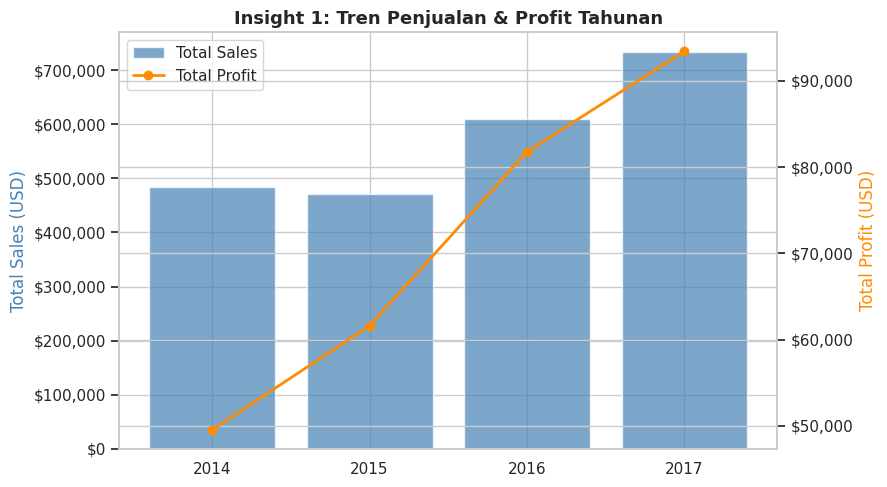

 year  Total_Sales  Total_Profit  Profit_Margin
 2014  484247.4981    49543.9741          10.23
 2015  470532.5090    61618.6037          13.10
 2016  609205.5980    81795.1743          13.43
 2017  733215.2552    93439.2696          12.74


In [ ]:
# Gabungkan fact dengan dim_date untuk analisis
df_analysis = fact_sales.merge(dim_date, on='date_id')

yearly = df_analysis.groupby('year').agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum')
).reset_index()
yearly['Profit_Margin'] = (yearly['Total_Profit'] / yearly['Total_Sales'] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(yearly['year'], yearly['Total_Sales'], color='steelblue', alpha=0.7, label='Total Sales')
ax1.set_ylabel('Total Sales (USD)', color='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(yearly['year'], yearly['Total_Profit'], color='darkorange', marker='o', linewidth=2, label='Total Profit')
ax2.set_ylabel('Total Profit (USD)', color='darkorange')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.title('Insight 1: Tren Penjualan & Profit Tahunan', fontsize=13, fontweight='bold')
ax1.set_xticks(yearly['year'])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig('insight1_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(yearly.to_string(index=False))

### Insight 2 — Profit per Kategori Produk

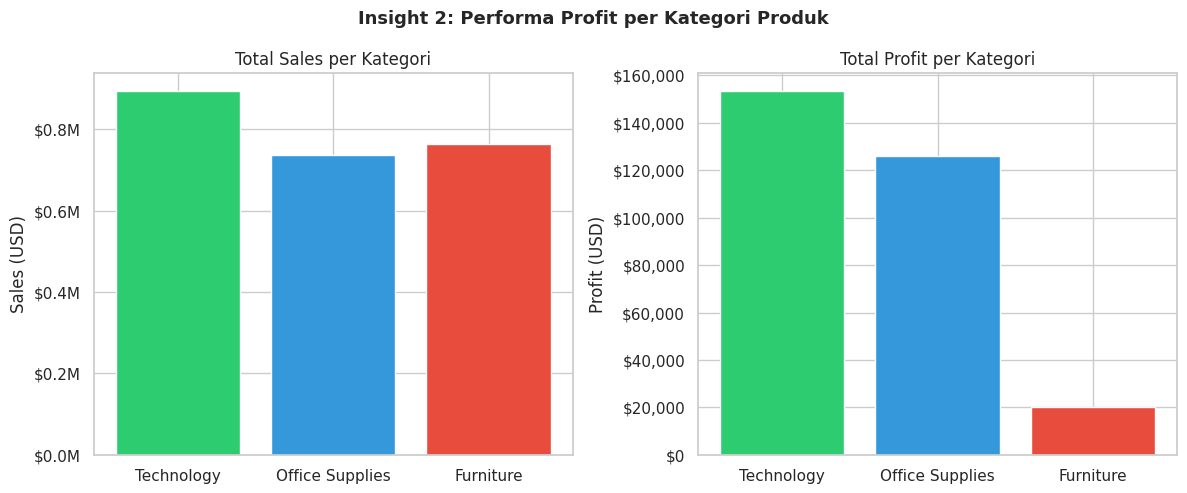

       category  Total_Sales  Total_Profit  Margin_%
     Technology  893633.2820   153415.7018     17.17
Office Supplies  736748.5940   126113.3459     17.12
      Furniture  764284.6523    20098.8892      2.63


In [ ]:
df_cat = fact_sales.merge(dim_product, on='product_id')
cat_profit = df_cat.groupby('category').agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum')
).reset_index().sort_values('Total_Profit', ascending=False)
cat_profit['Margin_%'] = (cat_profit['Total_Profit'] / cat_profit['Total_Sales'] * 100).round(2)

colors = ['#2ecc71', '#3498db', '#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(cat_profit['category'], cat_profit['Total_Sales'], color=colors)
axes[0].set_title('Total Sales per Kategori')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_ylabel('Sales (USD)')

axes[1].bar(cat_profit['category'], cat_profit['Total_Profit'], color=colors)
axes[1].set_title('Total Profit per Kategori')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_ylabel('Profit (USD)')

fig.suptitle('Insight 2: Performa Profit per Kategori Produk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('insight2_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(cat_profit.to_string(index=False))

### Insight 3 — Perbandingan Profit per Region

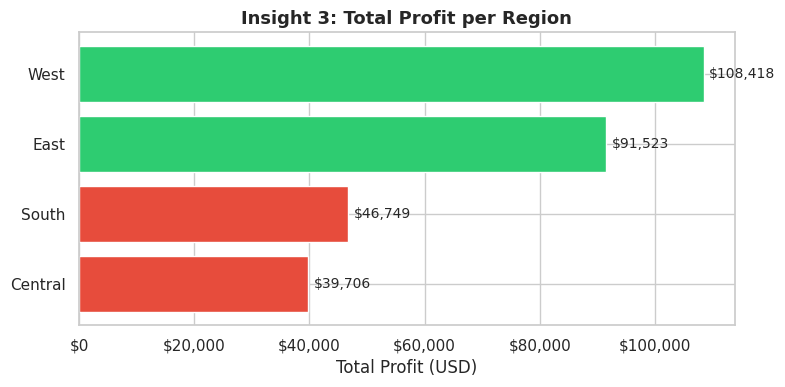

In [ ]:
df_reg = fact_sales.merge(dim_location, on='location_id')
reg_perf = df_reg.groupby('region').agg(
    Total_Sales=('sales', 'sum'),
    Total_Profit=('profit', 'sum')
).reset_index().sort_values('Total_Profit', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(reg_perf['region'], reg_perf['Total_Profit'],
               color=['#e74c3c' if x < 50000 else '#2ecc71' for x in reg_perf['Total_Profit']])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, reg_perf['Total_Profit']):
    ax.text(val + 1000, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=10)

ax.set_title('Insight 3: Total Profit per Region', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Profit (USD)')
plt.tight_layout()
plt.savefig('insight3_region.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight 4 — Dampak Diskon terhadap Profit

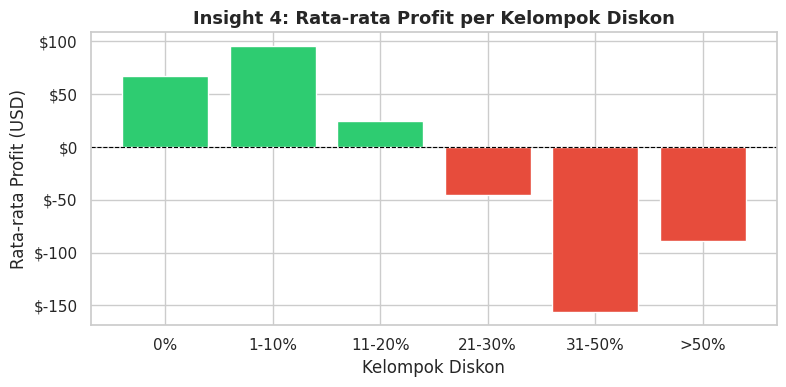

discount_bucket      profit
             0%   66.900292
          1-10%   96.055074
         11-20%   24.738824
         21-30%  -45.679636
         31-50% -156.282991
           >50%  -89.438144


In [ ]:
# Kelompokkan diskon ke dalam bucket
bins = [-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0]
labels = ['0%', '1-10%', '11-20%', '21-30%', '31-50%', '>50%']
fact_sales['discount_bucket'] = pd.cut(fact_sales['discount'], bins=bins, labels=labels)

disc_profit = fact_sales.groupby('discount_bucket', observed=True)['profit'].mean().reset_index()

colors_d = ['#2ecc71' if x >= 0 else '#e74c3c' for x in disc_profit['profit']]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(disc_profit['discount_bucket'], disc_profit['profit'], color=colors_d, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Insight 4: Rata-rata Profit per Kelompok Diskon', fontsize=13, fontweight='bold')
ax.set_xlabel('Kelompok Diskon')
ax.set_ylabel('Rata-rata Profit (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('insight4_discount.png', dpi=150, bbox_inches='tight')
plt.show()
print(disc_profit.to_string(index=False))

### Insight 5 — Top 5 Sub-Kategori berdasarkan Sales

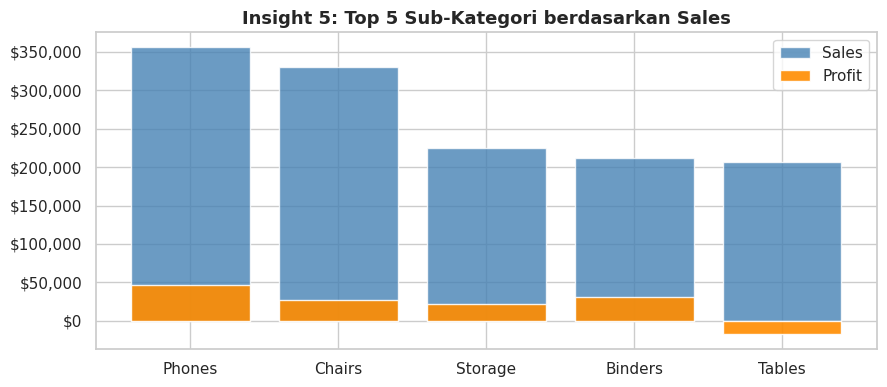

sub_category      Sales      Profit
      Phones 356702.354  46936.1861
      Chairs 330891.127  26707.6526
     Storage 224958.560  21408.7032
     Binders 211231.721  30373.2020
      Tables 206965.532 -17725.4811


In [ ]:
top_subcat = df_cat.groupby('sub_category').agg(
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum')
).reset_index().sort_values('Sales', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(top_subcat))
bars = ax.bar(x, top_subcat['Sales'], color='steelblue', alpha=0.8, label='Sales')
ax.bar(x, top_subcat['Profit'], color='darkorange', alpha=0.9, label='Profit')
ax.set_xticks(list(x))
ax.set_xticklabels(top_subcat['sub_category'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Insight 5: Top 5 Sub-Kategori berdasarkan Sales', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('insight5_subcategory.png', dpi=150, bbox_inches='tight')
plt.show()
print(top_subcat.to_string(index=False))

---
## 6. Ringkasan Eksekutif

In [ ]:
total_sales  = fact_sales['sales'].sum()
total_profit = fact_sales['profit'].sum()
margin       = total_profit / total_sales * 100
total_orders = fact_sales['order_id'].nunique()
total_customers = dim_customer.shape[0]

print('=' * 45)
print('       RINGKASAN DATA WAREHOUSE')
print('=' * 45)
print(f'  Total Transaksi   : {len(fact_sales):,}')
print(f'  Total Order       : {total_orders:,}')
print(f'  Total Pelanggan   : {total_customers:,}')
print(f'  Total Sales       : ${total_sales:,.2f}')
print(f'  Total Profit      : ${total_profit:,.2f}')
print(f'  Profit Margin     : {margin:.2f}%')
print('=' * 45)
print()
print('Star Schema Tables:')
for name, tbl in tables.items():
    print(f'  {name:<20}: {tbl.shape[0]:>5} baris')

       RINGKASAN DATA WAREHOUSE
  Total Transaksi   : 9,994
  Total Order       : 5,009
  Total Pelanggan   : 793
  Total Sales       : $2,297,200.86
  Total Profit      : $286,397.02
  Profit Margin     : 12.47%

Star Schema Tables:
  fact_sales          :  9994 baris
  dim_date            :  1237 baris
  dim_customer        :   793 baris
  dim_product         :  1894 baris
  dim_location        :   604 baris
  dim_shipment        :     4 baris
